# Come l'evoluzione della società ha ridisegnato il mondo degli anime

Il database di MyAnimeList raccoglie 28.955 anime, oltre 337.000 utenti e più di 124 milioni di valutazioni. Analizzati nel tempo, questi dati mostrano come il mercato sia cambiato dagli anni '90, chi guarda cosa, e perché.

 Cinque domande guidano l'analisi:
  - La composizione della produzione anime è davvero cambiata, e quando?
  - L'hype iniziale è temporaneo o esistono anime che resistono nel tempo?
  - Uomini e donne guardano cose così diverse?
  - Ogni generazione ha i suoi anime, o i gusti convergono?
  - La geografia predice il consumo, e fino a che punto?

 Cominciamo con l'import delle librerie e il caricamento dei dataset. Per questa analisi useremo i seguenti datasets:
 - **details**: contiene le informazioni di ogni anime come titolo, generi, anno di uscita, score, members e favorites
  - **profiles**: raccoglie i dati degli utenti registrati come genere, anno di nascita e paese.
  - **ratings**: è il dataset più grande, con oltre 124 milioni di valutazioni che collegano utenti e anime.

  Da details costruiamo **details_ex**, una versione esplosa per genere che useremo in tutto il
  notebook per aggregare i dati per categoria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '../datasets_cleaned/'

details  = pd.read_csv(DATA_PATH + 'details_clean.csv')
profiles = pd.read_csv(DATA_PATH + 'profiles_clean.csv')
ratings  = pd.read_csv(DATA_PATH + 'ratings_clean.csv')

print('details: ', details.shape)
print('profiles:', profiles.shape)
print('ratings:', ratings.shape)

details_ex = (
    details
    .assign(genre=details['genres'].str[2:-2].str.split("', '"))
    .explode('genre')
)
details_ex = details_ex[details_ex['genre'].str.strip() != ''][['mal_id', 'genre']]

top_genres = details_ex['genre'].value_counts().index
print('Generi totali:', list(top_genres))

details:  (28955, 28)
profiles: (335476, 10)
ratings: (123335299, 6)
Generi totali: ['Comedy', 'Fantasy', 'Action', 'Adventure', 'Sci-Fi', 'Drama', 'Romance', 'Slice of Life', 'Hentai', 'Supernatural', 'Avant Garde', 'Mystery', 'Ecchi', 'Sports', 'Horror', 'Suspense', 'Award Winning', 'Gourmet', 'Boys Love', 'Girls Love', 'Erotica']


## Il mondo anime non è solo serie TV

Quando si parla di anime, le persone tendono a pensare alle serie ma il database di MAL rivela una realtà più complessa composta da quasi 29.000 titoli e nove formati diversi.

- Serie TV e ONA: Per il grande pubblico e lo streaming.
- Film e OVA: Per narrazioni autoriali o approfondimenti per i fan.
- Special e Musicali: Formati brevi e sperimentali.

Comprendere queste distinzioni è essenziale: il formato non è solo un contenitore, ma definisce il target e la struttura del racconto.

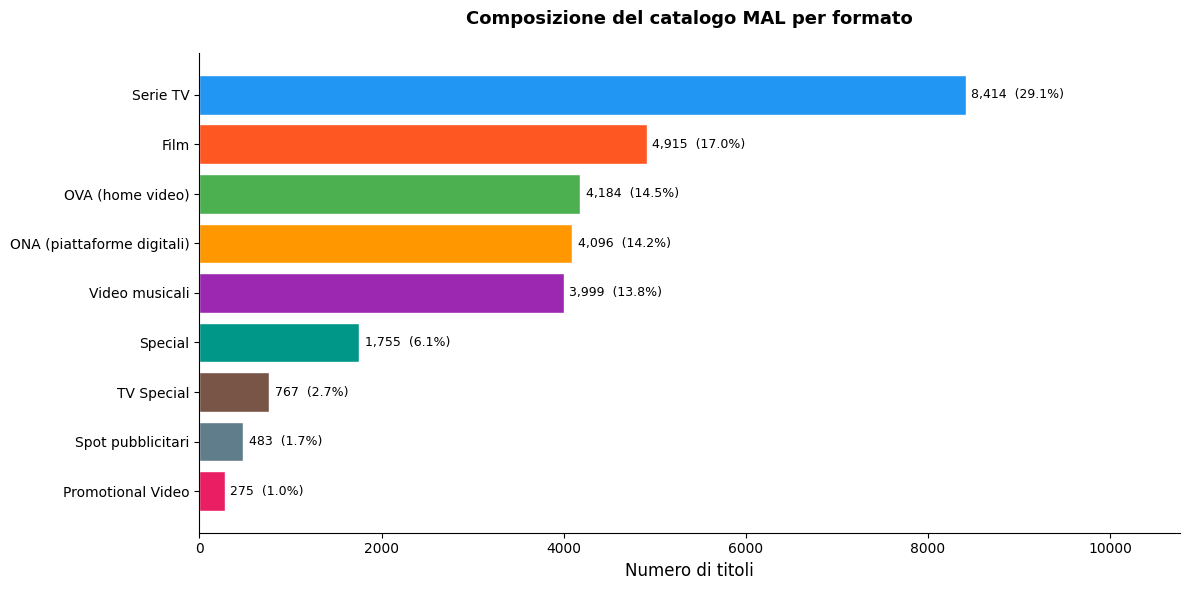

In [2]:
type_counts = details['type'].value_counts().reset_index()
type_counts.columns = ['type', 'count']
type_counts['pct'] = type_counts['count'] / type_counts['count'].sum() * 100

type_labels = {
    'TV':         'Serie TV',
    'Movie':      'Film',
    'OVA':        'OVA (home video)',
    'ONA':        'ONA (piattaforme digitali)',
    'Music':      'Video musicali',
    'Special':    'Special',
    'TV Special': 'TV Special',
    'CM':         'Spot pubblicitari',
    'PV':         'Promotional Video',
}
type_counts['label'] = type_counts['type'].map(type_labels).fillna(type_counts['type'])

palette = [
    '#2196F3', '#FF5722', '#4CAF50', '#FF9800',
    '#9C27B0', '#009688', '#795548', '#607D8B', '#E91E63'
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(type_counts['label'][::-1], type_counts['count'][::-1],
               color=palette[:len(type_counts)][::-1], edgecolor='white')

for bar, (_, row) in zip(bars, type_counts[::-1].iterrows()):
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
            f"{row['count']:,}  ({row['pct']:.1f}%)",
            va='center', fontsize=9)

ax.set_xlabel('Numero di titoli', fontsize=12)
ax.set_title('Composizione del catalogo MAL per formato\n',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, type_counts['count'].max() * 1.28)
plt.tight_layout()
plt.show()

Quattro formati su nove hanno un peso narrativo reale nella nostra analisi: **TV, Movie, OVA e ONA**. Gli altri cinque (Music, CM, PV, Special e TV Special) sono contenuti accessori o promozionali che non aggiungono significato alle domande che ci poniamo.

Sappiamo già cosa sono le serie TV e film. Vediamo a cosa si riferiscono OVA e ONA.

**OVA — Original Video Animation**
Contenuti prodotti direttamente per il mercato home video, senza passare dalla televisione né dal cinema.

**ONA — Original Net Animation**
La versione digitale dell'OVA: contenuti distribuiti direttamente su internet, senza passare da televisione, cinema o supporto fisico.

Da questo punto in poi, `details` è filtrato a questi quattro formati (21.609 titoli su 28.955).

Prima di proseguire, osserviamo come è cambiato il peso di questi formati nel tempo: la produzione anime si è evoluta non solo nei contenuti, ma anche nelle modalità di distribuzione, spinte dal progresso tecnologico e dalla diffusione del web.

In [3]:
import datetime
import plotly.graph_objects as go

MAIN_TYPES  = ['TV', 'Movie', 'OVA', 'ONA']
type_colors = {'TV': '#2196F3', 'Movie': '#FF5722', 'OVA': '#4CAF50', 'ONA': '#FF9800'}

current_year = datetime.datetime.now().year

# Nel CSV la colonna 'year' è popolata solo per i titoli TV;
# per Movie, OVA e ONA l'anno va derivato da start_date.
details_plot = details.copy()
details_plot['year'] = details_plot['year'].fillna(
    pd.to_datetime(details_plot['start_date'], utc=True, errors='coerce').dt.year
)

max_year = int(min(details_plot['year'].dropna().max(), current_year - 1))

type_year = (
    details_plot
    .dropna(subset=['year'])
    .query('type in @MAIN_TYPES and year >= 1990 and year <= @max_year')
    .groupby(['year', 'type'])
    .size()
    .reset_index(name='count')
)

fig = go.Figure()
for t in MAIN_TYPES:
    d = type_year[type_year['type'] == t].sort_values('year')
    fig.add_trace(go.Scatter(
        x=d['year'],
        y=d['count'],
        mode='lines+markers',
        name=t,
        line=dict(color=type_colors[t], width=2.2),
        marker=dict(size=5),
        hovertemplate='<b>%{fullData.name}</b><br>Anno: %{x:.0f}<br>Titoli: %{y}<extra></extra>',
    ))

fig.update_layout(
    title=dict(
        text=(
            f"Evoluzione della produzione per formato (1990–{max_year})<br>"
            "<sup>L'ONA cresce con lo streaming, l'OVA declina dopo il picco degli anni '90</sup>"
        ),
        font=dict(size=15),
    ),
    xaxis=dict(title='Anno', tickformat='d'),
    yaxis=dict(title='Numero di titoli prodotti'),
    legend=dict(font=dict(size=11)),
    hovermode='x unified',
    template='plotly_white',
    width=980,
    height=480,
)
fig.show()

# Filtro globale: da qui in poi details contiene solo i 4 formati principali
# L'anno derivato da start_date viene propagato in details così le celle
# successive che usano details[['mal_id', 'year']] trovano dati completi.
details = details[details['type'].isin(MAIN_TYPES)].copy().reset_index(drop=True)
details['year'] = details['year'].fillna(
    pd.to_datetime(details['start_date'], utc=True, errors='coerce').dt.year
)
details_ex = (
    details
    .assign(genre=details['genres'].str[2:-2].str.split("', '"))
    .explode('genre')
)
details_ex = details_ex[details_ex['genre'].str.strip() != ''][['mal_id', 'genre']]
top_genres = details_ex['genre'].value_counts().index

print(f'details filtrato: {len(details):,} titoli  →  {MAIN_TYPES}')
print(f'Generi unici dopo il filtro: {len(top_genres)}')

details filtrato: 21,609 titoli  →  ['TV', 'Movie', 'OVA', 'ONA']
Generi unici dopo il filtro: 21


### Gli anni '90: l'era dell'OVA e del supporto fisico

Negli anni '90' l'OVA è il formato dominante — con picchi di **124 titoli nel 1991** e **168 nel 2001** — mentre la TV si mantiene sotto i 60 titoli annui fino al 1997. Questa dominanza è il riflesso diretto del mercato del supporto fisico. Il VHS prima, il Laserdisc poi e il DVD a fine decennio rendevano l'OVA il formato ideale per la distribuzione, senza passare dalla rete televisiva.

### 2000–2010: internet arriva, l'ONA nasce

I primi ONA compaiono nel dataset nel **1998–1999**, quasi esperimenti isolati. La loro crescita rispecchia fedelmente la diffusione della connessione a internet: **6 nel 2000, 25 nel 2005, 54 nel 2009**. È il periodo in cui YouTube viene fondato (2005) in cui le prime piattaforme streaming iniziano a testare la distribuzione di contenuti animati.

La TV mantiene la popolarità: **232 titoli nel 2006, 261 nel 2010**. La digitalizzazione rende l'accesso più semplice ai contenuti via internet e la crescita della cultura anime al di fuori del Giappone.

### 2010–2019: lo streaming ridisegna il mercato

Il decennio successivo segna il sorpasso definitivo dell'ONA sull'OVA. L'ONA passa da **85 titoli nel 2011 a 294 nel 2017**, mentre l'OVA scende da **147 a 93** nello stesso periodo. Il turning point è intorno al **2013–2014**, quando Crunchyroll supera il milione di abbonati e Netflix inizia ad espandersi globalmente.

La TV rimane dominante con **376 titoli nel 2016**, il picco storico, ma l'ONA cresce abbastanza velocemente fino a raggiungerla. Il Film si mantiene abbastanza costante con **181–192 titoli tra 2017 e 2019**.

### 2020: il Covid spezza le linee in modo asimmetrico

Il **2020** è leggibile a colpo d'occhio sul grafico: tutte e quattro le linee scendono, ma con intensità molto diverse a seconda del formato.

| Formato | 2019 | 2020 | Calo |
|---------|------|------|------|
| **Movie** | 181 | 110 | **−39%** |
| **TV** | 326 | 312 | −4% |
| **ONA** | 321 | 317 | −1% |
| **OVA** | 62 | 64 | +3% |

Il Film è il formato più colpito: la chiusura delle sale cinematografiche in Giappone e nel mondo blocca le uscite pianificate e rimanda le produzioni in fase finale. La TV subisce ritardi nelle produzioni: studi di animazione chiusi, doppiatori in smart working, pipeline interrotte, etc. Alcune produzioni vengono semplicemente spostate alla stagione successiva.

L'ONA è quasi immune: **nativamente digitale**, non dipende da sale né da supply chain fisiche. La produzione può continuare da remoto con strumenti già in uso. In alcuni casi il Covid ha addirittura accelerato la scelta di distribuire contenuti originali sulle piattaforme invece che in TV.

### 2021–2024: il rimbalzo e il nuovo equilibrio

La ripresa non è uniforme. Il **2021** è paradossalmente l'anno peggiore per la TV (**263 titoli**, il minimo dal 2009): le produzioni bloccate nel 2020 non si recuperano tutte in un colpo, e i ritardi si propagano. Dal **2022 in poi la TV risale**, mentre ONA e Movie raggiungono un nuovo equilibrio stabile intorno a valori pre-Covid.

Il dato più significativo del periodo post-Covid è strutturale: **l'ONA ha stabilmente sorpassato la TV** dal 2018 in poi. Non è un effetto temporaneo. È la conferma che il mercato anime si è riorganizzato attorno alle piattaforme di streaming, lo stesso processo che, nel mondo della musica, ha portato dal CD allo streaming in meno di vent'anni.

## C'è stato un cambiamento in base ai generi?

In [4]:
import plotly.graph_objects as go

genre_totals = (
    details_ex['genre']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'genre', 'count': 'count'})
    .head(15)
)

fig = go.Figure(go.Pie(
    labels=genre_totals['genre'],
    values=genre_totals['count'],
    hole=0.35,
    textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>Titoli: %{value:,}<br>%{percent}<extra></extra>',
    textfont=dict(size=11),
))

fig.update_layout(
    title=dict(
        text='Distribuzione dei titoli per genere (top 15)<br><sup>Basato sui 4 formati principali: TV, Movie, OVA, ONA</sup>',
        font=dict(size=15),
    ),
    legend=dict(font=dict(size=11), orientation='v'),
    width=800,
    height=550,
)
fig.show()

A colpo d'occhio, si vede una dominanza del genere comedy. Dobbiamo però tenere in considerazione che tanti titoli hanno più di un genere. Chi è cresciuto negli anni '90 sicuramente ricorderà un panorama dominato da titoli come Dragon Ball, Gundam, Evangelion, etc.

C'è stato negli anni un cambiamento nei gusti per quanto riguarda i generi?

Nel grafico che segue ogni barra rappresenta un genere e la sua lunghezza indica la quota percentuale sul totale degli anime prodotti in quell'anno. Vediamo come sono cambiate le percentuali nell'arco degli anni. Ci concentriamo sugli 8 generi più prevalenti.

In [5]:
import datetime
import plotly.graph_objects as go
import plotly.express as px

current_year = datetime.datetime.now().year
max_year = int(min(details['year'].dropna().max(), current_year - 1))

genre_year = (
    details_ex
    .merge(details[['mal_id', 'year']], on='mal_id')
    .dropna(subset=['year'])
    .query('year >= 1990 and year <= @max_year')
    .query('genre in @top_genres')
    .groupby(['year', 'genre'])
    .size()
    .reset_index(name='count')
)

top8 = details_ex['genre'].value_counts().head(8).index

pivot_abs = (
    genre_year
    .query('genre in @top8')
    .pivot(index='year', columns='genre', values='count')
    .fillna(0)[top8]
)
pivot_pct = pivot_abs.div(pivot_abs.sum(axis=1), axis=0) * 100

# Anno di svolta
dominant        = pivot_pct.idxmax(axis=1)
genre_before    = dominant.iloc[0]
genre_after     = dominant.value_counts().drop(genre_before, errors='ignore').idxmax()
switchover_year = int(dominant[dominant == genre_after].index.min())

print(f'Genere dominante prima del {switchover_year}: {genre_before}')
print(f'Genere dominante dal {switchover_year}: {genre_after}')

# Palette fissa per genere — stessa per tutti i frame
palette = dict(zip(top8, px.colors.qualitative.Set2[:len(top8)]))

years = sorted(pivot_pct.index.astype(int))
x_max = pivot_pct.values.max() * 1.18

def make_bar(year):
    row = pivot_pct.loc[year].sort_values(ascending=True)
    return go.Bar(
        x=row.values.round(2),
        y=list(row.index),
        orientation='h',
        marker_color=[palette[g] for g in row.index],
        text=[f'{v:.1f}%' for v in row.values],
        textposition='outside',
        cliponaxis=False,
        hovertemplate='<b>%{y}</b><br>Quota: %{x:.1f}%<extra></extra>',
    )

frames = [
    go.Frame(data=[make_bar(y)], name=str(y))
    for y in years
]

fig = go.Figure(
    data=[make_bar(years[0])],
    frames=frames,
)

fig.update_layout(
    title=dict(
        text=(
            f'Quota % per genere nella produzione anime — ogni anno la classifica cambia<br>'
            f'<sup>Dal {switchover_year} "{genre_after}" supera "{genre_before}" e non torna più indietro</sup>'
        ),
        font=dict(size=15),
    ),
    xaxis=dict(title='% del totale annuo', range=[0, x_max], ticksuffix='%', fixedrange=True),
    yaxis=dict(title='', fixedrange=True),
    template='plotly_white',
    width=900,
    height=480,
    showlegend=False,
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=1.15,
        x=0.0,
        xanchor='left',
        buttons=[
            dict(
                label='▶  Play',
                method='animate',
                args=[None, dict(
                    frame=dict(duration=300, redraw=True),
                    fromcurrent=True,
                    transition=dict(duration=200, easing='cubic-in-out'),
                )],
            ),
            dict(
                label='⏸  Pausa',
                method='animate',
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode='immediate',
                    transition=dict(duration=0),
                )],
            ),
        ],
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Anno: ', font=dict(size=13)),
        pad=dict(t=10),
        steps=[
            dict(
                method='animate',
                label=str(y),
                args=[[str(y)], dict(
                    frame=dict(duration=300, redraw=True),
                    mode='immediate',
                    transition=dict(duration=200),
                )],
            )
            for y in years
        ],
    )],
)

fig.show()

Genere dominante prima del 1993: Comedy
Genere dominante dal 1993: Fantasy


Nell arco degli anni, si osserva un' oscillazione costante tra i diversi generi rivelando un pattern più sfumato di quello che ci si aspetta. I quattro generi protagonisti sono sempre gli stessi: Comedy, Fantasy, Action e Adventure che si scambiano tra loro.

Comedy domina quasi ininterrottamente dal 1990 al 2018: ventotto anni in testa, con un'unica eccezione nel **1993**, quando Fantasy si prende il primo posto per un anno solo prima di cederlo di nuovo. **2019 è l'anno del primo sorpasso vero**: Fantasy supera Comedy per la prima volta a **22.3% contro 22.2%**, praticamente un pareggio.

La svolta definitiva arriva nel **2023–2024**: Fantasy si attesta al primo posto, ma la vera novità è che **Action sale al secondo posto** e Comedy scende al terzo per la prima volta in trent'anni.

L'unico genere diverso da questi 4 che nell'arco degli anni ha avuto dei picchi è Drama che negli anni **1993, 2000, 2004 e 2005** è salito nel top 4 prendendo il posto di Adventure.

## Hype vs. Longevità

Nel corso degli anni si sono osservati due fenomeni che riguardano gli anime: quelli che esplodono e si consumano, e quelli che crescono lentamente e non si dimenticano.

Per analizzare questi due tipi, possiamo sfruttare queste tre metriche diverse:

- **`members`**: quante persone hanno *aggiunto* l'anime alla loro lista che misura l'esposizione e l'hype iniziale
- **`favorites`**: quante persone lo hanno marcato come preferito che misura l'apprezzamento nel tempo dei fan
- **`score`**: la valutazione media che misura la qualità percepita

Il rapporto tra queste tre metriche è la chiave. Un anime con molti members e pochi favorites è un titolo che ha attirato curiosità ma non ha lasciato il segno. Un anime con pochi members e molti favorites è stato visto da pochi ma ha creato il suo fanbase.

Vediamo i top 5 anime per ciascuna di queste metriche per vedere se corrispondono.


In [6]:
# Filtra: almeno 1000 membri, score presente
df = details.dropna(subset=['score', 'members', 'favorites']).copy()
df = df[df['members'] >= 1000].copy()

# Indici derivati
df['fav_ratio']  = df['favorites'] / df['members']
df['hype_index'] = np.log1p(df['members'])
df['love_index'] = np.log1p(df['favorites'])

import plotly.graph_objects as go
from plotly.subplots import make_subplots

top_members_5   = df.nlargest(10, 'members').reset_index(drop=True)
top_favorites_5 = df.nlargest(10, 'favorites').reset_index(drop=True)
top_score_5     = df.nlargest(10, 'score').reset_index(drop=True)

shared = (
    (set(top_members_5['title']) & set(top_favorites_5['title'])) |
    (set(top_members_5['title']) & set(top_score_5['title']))   |
    (set(top_favorites_5['title']) & set(top_score_5['title']))
)

def shorten(t, n=20):
    return t if len(t) <= n else t[:n] + '...'


panels = [
    (top_members_5,   'members',   'Top 10 per Members<br><sup>(hype)</sup>',         ',.0f'),
    (top_favorites_5, 'favorites', 'Top 10 per Favorites<br><sup>(longevità)</sup>', ',.0f'),
    (top_score_5,     'score',     'Top 10 per Score<br><sup>(qualità)</sup>',        '.2f'),
]

fig = make_subplots(rows=1, cols=3, subplot_titles=[p[2] for p in panels],
                    horizontal_spacing=0.15)

for col_idx, (data, metric, _, fmt) in enumerate(panels, start=1):
    colors = ['#e07b3a' if t in shared else '#5c8ee0' for t in data['title']]
    labels = [shorten(t) for t in data['title']]
    fig.add_trace(go.Bar(
        x=data[metric].values[::-1],
        y=labels[::-1],
        orientation='h',
        marker_color=colors[::-1],
        customdata=data[['title', metric]].values[::-1],
        hovertemplate='<b>%{customdata[0]}</b><br>Valore: %{customdata[1]:,.0f}<extra></extra>'
            if metric != "score" else
        '<b>%{customdata[0]}</b><br>Score: %{customdata[1]:.2f}<extra></extra>',
        showlegend=False,
    ), row=1, col=col_idx)

score_vals = top_score_5["score"].values
fig.update_xaxes(range=[score_vals.min() - 0.3, score_vals.max() + 0.3], row=1, col=3)
fig.update_xaxes(dtick=500_000, row=1, col=1)
fig.update_xaxes(dtick=500_000, row=1, col=2)
fig.update_xaxes(dtick=0.1, row=1, col=3)

for col_idx in [1, 2, 3]:
    fig.update_yaxes(tickfont=dict(size=10), row=1, col=col_idx)

for name, color in [("Appare in piu classifiche", "#e07b3a"), ("Solo in questa", "#5c8ee0")]:
    fig.add_trace(go.Bar(x=[None], y=[None], orientation="h",
                         marker_color=color, name=name, showlegend=True))

fig.update_layout(
    template='plotly_white',
    height=700, width=1900,
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, xanchor='center', x=0.5),
)
fig.show()


Si nota che i titoli che compaiono in più di una classifica sono una minoranza e questo rimarca il fatto che hype, longevità e qualità non siano sinonimi.
Vediamo titoli come Shingeki no Kyojin (Attack on Titans) oppure Death Note che compiono su tutte e tre le classifiche, mentre titoli come One Piece e Naruto no anche se sono tra i più famosi.

La classifica per **members** e dominata da titoli ad alto impatto mediatico che hanno fatto rumore. Ma avere tanti members non significa essere amati: solo tre da questi titoli compaiono nella top dieci per favorites.

La classifica per **favorites** racconta una storia diversa. Da questi titoli la metà non compare negli altri top dieci il che significa che questi titoli hanno un fanbase a prescindere dal punteggio basso di hype e qualità.

La classifica per **score** dimostra che solo tre su dieci compaiono nelle altre categorie e che quindi la qualità percepita non dipende necessariamente da hype e popolarità.


## La Mappa Hype vs Longevità

La visualizzazione centrale di questa analisi è uno scatter plot che posiziona ogni anime in uno spazio bidimensionale: sull'asse x il numero di members (hype/esposizione), sull'asse y il rapporto favorites/members (longevità/amore relativo).

Questo spazio si divide in quattro quadranti naturali:
- **Alto destra**: grande hype E grande longevità — i capolavori universali
- **Alto sinistra**: piccolo hype ma alta longevità — i cult nascosti
- **Basso destra**: grande hype ma bassa longevità — i fenomeni fugaci
- **Basso sinistra**: poco seguito e poco amato — il rumore di fondo

In [11]:
import plotly.graph_objects as go

med_members   = df["members"].median()
med_fav_ratio = df["fav_ratio"].median()

top_universal = df[(df["members"] > med_members) & (df["fav_ratio"] > med_fav_ratio)].nlargest(5, "fav_ratio")
top_cult      = df[(df["members"] <= med_members) & (df["fav_ratio"] > med_fav_ratio)].nlargest(5, "fav_ratio")
top_hype      = df[(df["members"] > med_members) & (df["fav_ratio"] <= med_fav_ratio)].nlargest(5, "members")
highlighted   = pd.concat([top_universal, top_cult, top_hype])

fig = go.Figure()

# Tutti i punti
fig.add_trace(go.Scatter(
    x=df["members"],
    y=df["fav_ratio"],
    mode="markers",
    marker=dict(
        size=5, opacity=0.25,
        color=df["score"],
        colorscale="RdYlGn", cmin=5, cmax=9,
        colorbar=dict(title="Score"),
        showscale=True,
    ),
    customdata=df[["title", "score", "members", "favorites"]].values,
    hovertemplate="<b>%{customdata[0]}</b><br>Score: %{customdata[1]:.2f}<br>Members: %{customdata[2]:,.0f}<br>Favorites: %{customdata[3]:,.0f}<extra></extra>",
    showlegend=False,
))

# Punti in evidenza con etichetta
fig.add_trace(go.Scatter(
    x=highlighted["members"],
    y=highlighted["fav_ratio"],
    mode="markers+text",
    marker=dict(
        size=10, opacity=1,
        color=highlighted["score"],
        colorscale="RdYlGn", cmin=5, cmax=9,
        line=dict(color="black", width=1),
        showscale=False,
    ),
    text=highlighted["title"].str[:18],
    textposition="top right",
    textfont=dict(size=8),
    customdata=highlighted[["title", "score", "members", "favorites"]].values,
    hovertemplate="<b>%{customdata[0]}</b><br>Score: %{customdata[1]:.2f}<br>Members: %{customdata[2]:,.0f}<br>Favorites: %{customdata[3]:,.0f}<extra></extra>",
    showlegend=False,
))

# Linee di mediana
fig.add_vline(x=med_members, line_dash="dash", line_color="gray", line_width=1, opacity=0.6)
fig.add_hline(y=med_fav_ratio, line_dash="dash", line_color="gray", line_width=1, opacity=0.6)

# Label quadranti (coordinate relative al plot area)
quadrants = [
    (0.78, 0.93, "CAPOLAVORI<br>UNIVERSALI", "darkgreen"),
    (0.08, 0.93, "CULT<br>NASCOSTI",          "steelblue"),
    (0.78, 0.07, "FENOMENI<br>FUGACI",        "darkred"),
    (0.08, 0.07, "RUMORE<br>DI FONDO",        "gray"),
]
for x, y, text, color in quadrants:
    fig.add_annotation(
        xref="paper", yref="paper", x=x, y=y,
        text=f"<b>{text}</b>",
        showarrow=False,
        font=dict(color=color, size=11),
        align="center",
        bgcolor="rgba(255,255,255,0.6)",
    )

fig.update_layout(
    title=dict(text="La Mappa Hype vs Longevita<br><sup>Ogni punto e un anime — il colore e lo score</sup>",
               font=dict(size=14)),
    xaxis=dict(type="log", title="Numero di Members (scala log)"),
    yaxis=dict(title="Rapporto Favorites/Members (Indice di Longevita)"),
    template="plotly_white",
    height=600, width=1000,
    hovermode="closest",
)
fig.show()


## L'Effetto del Tempo: i Vecchi Anime Resistono Meglio?

Una delle ipotesi più comuni nel fandom è che gli anime classici — quelli degli anni '90 e 2000 — abbiano un vantaggio strutturale nel rapporto favorites/members. La ragione sarebbe questa: chi guarda un anime del 1998 oggi lo fa *deliberatamente*, cercando un classico. Il pubblico casual non lo trova, non lo vede. Chi arriva a guardarlo è già predisposto ad amarlo.

Se questa ipotesi è corretta, dovremmo vedere il fav_ratio crescere sistematicamente con l'età dell'anime. Se invece il pattern è piatto o invertito, significa che la longevità dipende da qualcosa di intrinseco al titolo, non dall'effetto del tempo.

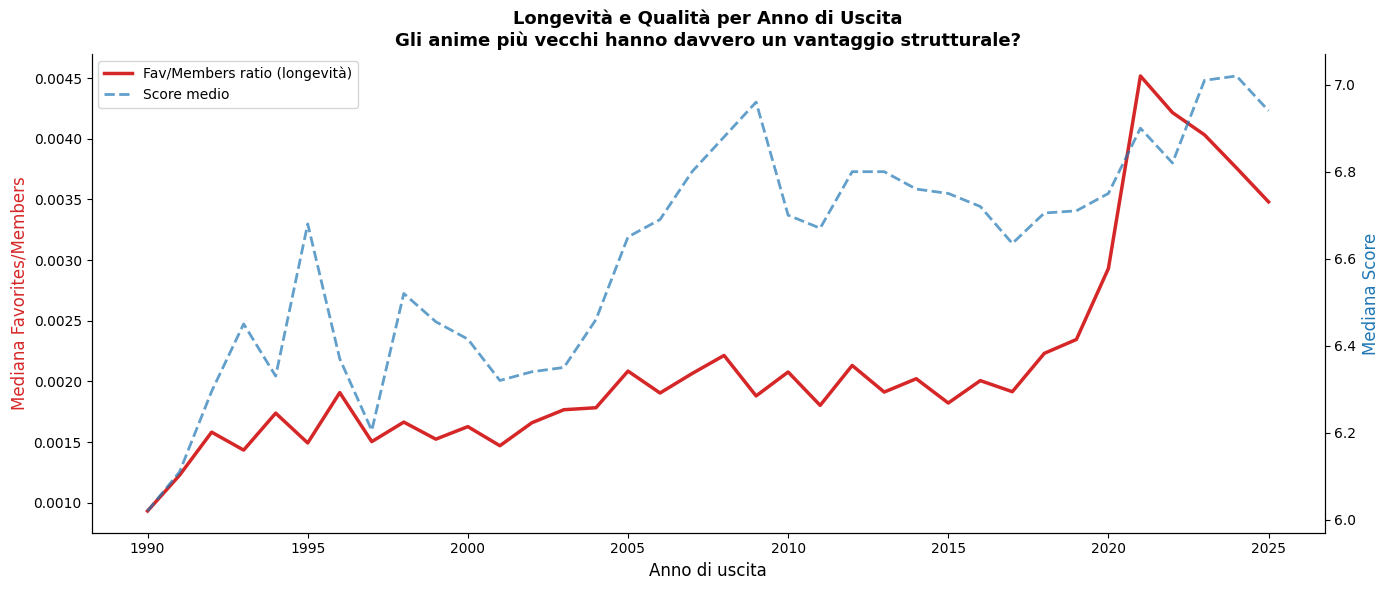

In [8]:
df_year = df.dropna(subset=['year']).copy()
df_year = df_year[(df_year['year'] >= 1990) & (df_year['year'] <= current_year - 1)].copy()
df_year['age'] = current_year - df_year['year']

# Media mobile del fav_ratio per anno
yearly = df_year.groupby('year').agg(
    median_fav_ratio=('fav_ratio', 'median'),
    median_score=('score', 'median'),
    count=('mal_id', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['median_fav_ratio'], color='#d62728', linewidth=2.5, label='Fav/Members ratio (longevità)')
ax2.plot(yearly['year'], yearly['median_score'], color='#1f77b4', linewidth=2, linestyle='--', alpha=0.7, label='Score medio')

ax1.set_ylabel('Mediana Favorites/Members', color='#d62728', fontsize=12)
ax2.set_ylabel('Mediana Score', color='#1f77b4', fontsize=12)
ax1.set_xlabel('Anno di uscita', fontsize=12)
ax1.set_title('Longevità e Qualità per Anno di Uscita\n'
              'Gli anime più vecchi hanno davvero un vantaggio strutturale?',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.show()

## I Generi che Resistono al Tempo

Esiste una dimensione ancora più specifica del rapporto hype/longevità: quella dei generi. Certi generi producono sistematicamente anime con alta retention (favorites/members alto) mentre altri producono fenomeni più effimeri?

Qui l'analisi diventa interessante perché incrocia due effetti: la struttura narrativa del genere (il Drama costruisce attaccamento, l'Action produce adrenalina che si consuma) e il tipo di audience che attira (l'audience del Seinen tende ad essere più selettiva di quella dello Shounen mainstream).

C:\Users\aless\AppData\Local\Temp\ipykernel_10252\1354707055.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



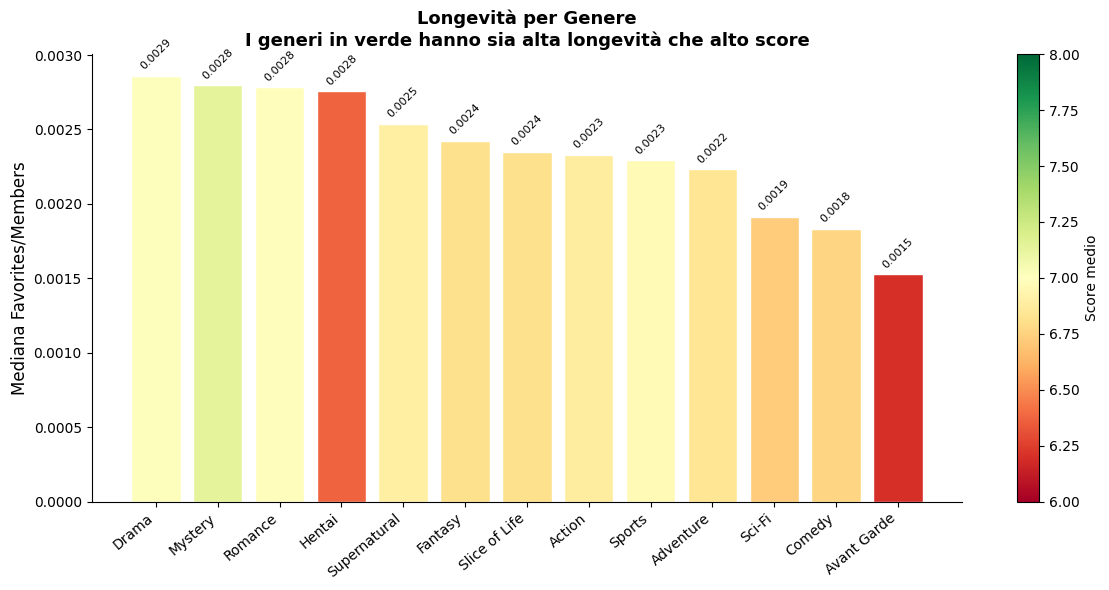

In [9]:
# Usa details_ex già definito in setup; seleziona top 13 generi per questo grafico
top_genres_lon = details_ex['genre'].value_counts().head(13).index.tolist()

df_genres = df.merge(details_ex, on='mal_id').query('genre in @top_genres_lon')

genre_stats = (
    df_genres.groupby('genre')
    .agg(median_fav_ratio=('fav_ratio', 'median'),
         median_score=('score', 'median'),
         count=('mal_id', 'nunique'))
    .sort_values('median_fav_ratio', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.interp(genre_stats['median_score'], [6, 8], [0.1, 0.9]))
bars = ax.bar(genre_stats.index, genre_stats['median_fav_ratio'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8, rotation=45)

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=6, vmax=8))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Score medio')

ax.set_xticklabels(genre_stats.index, rotation=40, ha='right')
ax.set_ylabel('Mediana Favorites/Members', fontsize=12)
ax.set_title('Longevità per Genere\nI generi in verde hanno sia alta longevità che alto score',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Uomini e donne guardano cose così diverse?

La prima variabile demografica da esaminare è il genere dell'utente. Il luogo comune è radicato nel fandom: gli uomini guardano Action ed Ecchi, le donne guardano Romance e Shoujo. Come ogni stereotipo, contiene un fondo di verità — ma quanto è grande quel fondo, e quanto è invece costruzione narrativa?

Per rispondere, abbiamo incrociato i profili utente (genere dichiarato: Male, Female) con i generi degli anime valutati, su un campione di oltre 2 milioni di rating. Per ogni genere, abbiamo calcolato la percentuale che occupa nel consumo totale di ciascun gruppo, poi abbiamo sottratto: Female meno Male. Il risultato è un grafico di divergenza che mostra, per ogni genere, chi lo guarda proporzionalmente di più — e di quanto.

Questo approccio è più informativo di un semplice confronto affiancato: permette di vedere immediatamente dove le differenze sono significative e dove invece i gusti convergono.

In [10]:
profiles_gen = profiles.loc[profiles['gender'].isin(['Male', 'Female'])]
r_gen        = ratings.merge(profiles_gen[['username', 'gender']], on='username')

counts_gen = (
    r_gen
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['gender', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_gen['pct'] = (
    counts_gen['count']
    / counts_gen.groupby('gender')['count'].transform('sum')
    * 100
)

pivot_gen = (
    counts_gen
    .pivot(index='genre', columns='gender', values='pct')
    .fillna(0)
    .sort_values('Female', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(pivot_gen))
width = 0.38

ax.bar(x - width/2, pivot_gen['Female'], width, label='Female', color='#e07b8a', edgecolor='white')
ax.bar(x + width/2, pivot_gen['Male'],   width, label='Male',   color='#5c8ee0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(pivot_gen.index, rotation=40, ha='right', fontsize=10)
ax.set_ylabel('% sul totale guardato per genere', fontsize=12)
ax.set_title('Distribuzione dei generi per uomini e donne\n'
             'Le differenze esistono ma sono concentrate in pochi generi',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 576. MiB for an array with shape (75459597,) and data type int64

Il risultato è più sfumato di quanto il luogo comune suggerisca. Sì, esistono differenze reali: Romance e Shoujo attraggono proporzionalmente più utenti femminili, mentre Ecchi e alcune categorie di azione attraggono più utenti maschili. Fin qui, lo stereotipo regge.

Quello che sorprende è l'entità delle differenze per tutto il resto. Action, Comedy, Fantasy, Adventure, Sci-Fi, Slice of Life — i generi che compongono la spina dorsale della produzione anime — mostrano differenze percentuali minime tra i due gruppi. Le barre sono corte. I gusti convergono.

Ma questa è una fotografia statica: ci dice com'è oggi, non com'è cambiato nel tempo. Se le norme sociali, l'open-mindedness e la dissoluzione degli stereotipi di genere hanno davvero influenzato il consumo di anime, dovremmo vederlo nel dato longitudinale: i gap si sono ridotti negli anni, o sono rimasti strutturali?

### I gap si stanno chiudendo? L'evoluzione nel tempo

Se il divario tra uomini e donne si fosse ridotto negli ultimi vent'anni, sarebbe un segnale preciso: non solo di gusti individuali che cambiano, ma di trasformazioni più profonde nelle norme sociali e nell'apertura culturale. I dati di MAL, che coprono due decenni di comportamenti registrati, permettono di rispondere a questa domanda con precisione.

Per ogni anno, abbiamo calcolato la differenza percentuale (Female − Male) per i generi in cui il gap è più marcato. Il grafico mostra come questo divario si sia evoluto nel tempo, con una media mobile a 3 anni per smussare le fluttuazioni annuali. Un valore che si avvicina allo zero indica convergenza — uomini e donne che si omologano nei gusti. Un valore stabile indica che il gap è strutturale, indipendente dai cambiamenti sociali.

In [ ]:
year_min_evo = 2005

r_evo = (
    r_gen
    .merge(details[['mal_id', 'year']], left_on='anime_id', right_on='mal_id')
    .merge(details_ex[['mal_id', 'genre']], on='mal_id')
    .dropna(subset=['year'])
    .query('year >= @year_min_evo and year <= @max_year')
    .query('genre in @top_genres')
)

counts_evo = (
    r_evo
    .groupby(['year', 'gender', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_evo['pct'] = (
    counts_evo['count']
    / counts_evo.groupby(['year', 'gender'])['count'].transform('sum')
    * 100
)

pivot_evo = (
    counts_evo
    .pivot_table(index=['year', 'genre'], columns='gender', values='pct', fill_value=0)
    .reset_index()
    .assign(diff=lambda df: df['Female'] - df['Male'])
)

# Generi con il gap assoluto medio più alto — i più "polarizzati" tra i generi
focus_genres = (
    pivot_evo
    .assign(abs_diff=pivot_evo['diff'].abs())
    .groupby('genre')['abs_diff']
    .mean()
    .nlargest(6)
    .index
)

gap_over_time = (
    pivot_evo
    .query('genre in @focus_genres')
    .pivot(index='year', columns='genre', values='diff')
    .rolling(3, center=True, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 7))
gap_over_time.plot(ax=ax, linewidth=2.2)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.set_ylabel('Differenza % (Female − Male)', fontsize=12)
ax.set_xlabel('Anno', fontsize=12)
ax.set_title(
    f'I gap di genere si stanno chiudendo? Evoluzione {year_min_evo}–{max_year}',
    fontsize=13, fontweight='bold'
)
ax.text(0.02, 0.97, '↑ Donne guardano proporzionalmente di più',
        transform=ax.transAxes, fontsize=9, color='steelblue', va='top')
ax.text(0.02, 0.03, '↓ Uomini guardano proporzionalmente di più',
        transform=ax.transAxes, fontsize=9, color='firebrick', va='bottom')
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Il grafico risponde alla domanda con più sfumatura di quanto ci si aspetti. I generi storicamente più polarizzati — quelli dove il gap era più marcato — mostrano ciascuno una traiettoria diversa nel tempo.

Dove il gap si riduce, la lettura è coerente con i cambiamenti sociali degli ultimi vent'anni: la progressiva normalizzazione di certi contenuti tra generi diversi, la diffusione delle piattaforme streaming che ha allargato il pubblico anime a demographic prima meno rappresentate, e la dissoluzione degli stigmi legati al "genere sbagliato" che guarda certi contenuti. Non è una rivoluzione: è un'erosione lenta e misurabile.

Dove il gap rimane stabile — o si allarga — il dato suggerisce invece che alcune preferenze sono più radicate nelle identità di genere che nelle norme sociali del momento. La linea tratteggiata a zero è il punto di indifferenza: ciò che vediamo sopra e sotto ci dice quali confini stiano cedendo e quali tengano.

Il genere dell'utente è un predittore debole dei gusti generali — ma per alcune categorie specifiche, il tempo non ha cambiato molto. La domanda che segue è se lo stesso pattern vale per un'altra variabile demografica: la generazione di appartenenza.

## Ogni generazione ha i suoi anime — o è solo un mito?

La narrativa generazionale nell'anime è potente. I Boomer e la Gen X hanno scoperto il medium in un'epoca di catalogo limitato, con titoli come Astro Boy, Lupin III e i grandi Drama degli anni '70 e '80. I Millennial sono cresciuti con Dragon Ball Z e Sailor Moon; la Gen Z con My Hero Academia e Demon Slayer. Sembra naturale ipotizzare che queste esperienze formative così diverse abbiano plasmato gusti strutturalmente differenti.

Per testare questa ipotesi, abbiamo classificato gli utenti in quattro generazioni in base all'anno di nascita — Boomer (1946–1964), Gen X (1965–1980), Millennial (1981–1996), Gen Z (1997–2012) — e analizzato la distribuzione dei generi anime guardati da ciascun gruppo. La heatmap mostra, per ogni combinazione generazione/genere, la percentuale sul consumo totale di quella coorte.

Se la narrativa generazionale fosse vera, ci aspetteremmo pattern molto diversi tra le righe. Se invece i gusti convergono, le righe si assomiglierebbero — come è già successo con il genere.

In [ ]:
profiles_bday = profiles.dropna(subset=['birthday']).copy()
profiles_bday['birth_year'] = pd.to_numeric(profiles_bday['birthday'], errors='coerce')
profiles_bday = profiles_bday.dropna(subset=['birth_year'])

bins   = [0, 1945, 1964, 1980, 1996, 2012, 9999]
labels = ['Silent', 'Boomer', 'Gen X', 'Millennial', 'Gen Z', 'Gen Alpha']
profiles_bday['generation'] = pd.cut(profiles_bday['birth_year'], bins=bins, labels=labels)

gen_focus = ['Boomer', 'Gen X', 'Millennial', 'Gen Z']
r_cohort  = ratings.merge(
    profiles_bday.loc[profiles_bday['generation'].isin(gen_focus), ['username', 'generation']],
    on='username'
)

counts_cohort = (
    r_cohort
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['generation', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_cohort['pct'] = (
    counts_cohort['count']
    / counts_cohort.groupby('generation')['count'].transform('sum')
    * 100
)

gen_pivot = (
    counts_cohort
    .pivot(index='generation', columns='genre', values='pct')
    .fillna(0)
    .reindex(gen_focus)
    [top_genres]
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(gen_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% sul totale guardato'})
ax.set_title('Boomer e Gen X si distinguono — Millennial e Gen Z convergono',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Genere Anime')
ax.set_ylabel('Generazione')

# Evidenzia la cella con la differenza massima tra Boomer e Gen Z
diff_row = (gen_pivot.loc['Boomer'] - gen_pivot.loc['Gen Z']).abs()
max_genre = diff_row.idxmax()
col_idx = list(gen_pivot.columns).index(max_genre)
ax.add_patch(plt.Rectangle((col_idx, 0), 1, len(gen_focus),
             fill=False, edgecolor='blue', lw=2.5, clip_on=False))
ax.text(col_idx + 0.5, -0.4, f'Max\ndivario', ha='center', fontsize=8,
        color='blue', fontweight='bold')

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

La heatmap rivela un pattern a gradiente: più si risale verso le generazioni più anziane, più i gusti si discostano da quelli delle generazioni recenti. Millennial e Gen Z sono quasi indistinguibili — Comedy, Fantasy, Action dominano entrambe in proporzioni quasi identiche. Gen X inizia a differenziarsi, con una quota più alta di Drama. I Boomer sono la generazione più distante: il loro profilo riflette un catalogo storicamente dominato da generi che oggi occupano uno spazio marginale nella produzione.

La spiegazione più plausibile non è che i Boomer abbiano "gusti diversi" per natura, ma che abbiano formato le loro preferenze su un catalogo strutturalmente diverso — e che quelle preferenze siano rimaste. È l'effetto della formazione precoce: il medium che si guarda a 15 anni lascia un'impronta più duratura di quello che si scopre a 30.

Il rettangolo blu evidenzia il genere con il divario massimo tra Boomer e Gen Z. È lì che la distanza generazionale è più leggibile nei dati.

Due variabili demografiche analizzate, e due volte la stessa conclusione di fondo: i gusti sono più uniformi di quanto ci si aspetti tra le generazioni più giovani. La vera frattura non è tra Millennial e Gen Z — è tra chi ha scoperto gli anime nel Novecento e chi li ha scoperti dopo. Rimane da testare la terza variabile — quella che, come vedremo, introduce più variazione di entrambe.

## La mappa geografica dei gusti: ogni paese ha il suo genere preferito?

Genere e generazione convergono più di quanto si pensi. La geografia racconta una storia diversa. Per verificarlo, abbiamo incrociato i profili utente con il loro paese dichiarato e i generi degli anime valutati, costruendo per ciascuno dei 15 paesi più rappresentati nel dataset la distribuzione percentuale dei generi consumati.

La heatmap che segue mostra, per ogni combinazione paese/genere, la quota che quel genere occupa sul totale delle visioni registrate da utenti di quel paese. Se i gusti fossero uniformi globalmente, tutte le righe si assomiglierebbero. Dove invece emergono differenze di colore tra paesi, stiamo vedendo variazione culturale reale nel consumo.

In [ ]:
top_countries = profiles['location'].dropna().value_counts().head(15).index
profiles_loc  = profiles.loc[profiles['location'].isin(top_countries), ['username', 'location']]

counts_country = (
    ratings
    .merge(profiles_loc, on='username')
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['location', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_country['pct'] = (
    counts_country['count']
    / counts_country.groupby('location')['count'].transform('sum')
    * 100
)

country_pivot = (
    counts_country
    .pivot(index='location', columns='genre', values='pct')
    .fillna(0)
    [top_genres]
)

# Ordina i paesi per similarità (genere con quota più alta)
country_pivot = country_pivot.loc[country_pivot.idxmax(axis=1).sort_values().index]

# Genere con la varianza più alta tra paesi (dove la geografia conta di più)
most_varied_genre = country_pivot.std(axis=0).idxmax()

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(country_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': '% sul totale guardato per paese'})
ax.set_title(f'I gusti variano geograficamente — "{most_varied_genre}" è il genere più polarizzante tra paesi',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Genere Anime')
ax.set_ylabel('Paese')

# Evidenzia la colonna del genere più variabile
col_idx = list(country_pivot.columns).index(most_varied_genre)
ax.add_patch(plt.Rectangle((col_idx, 0), 1, len(country_pivot),
             fill=False, edgecolor='blue', lw=2.5, clip_on=False))
ax.text(col_idx + 0.5, -0.3, 'Max\nvarianza', ha='center',
        fontsize=8, color='blue', fontweight='bold')

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Mapping nomi paese → ISO-3 (copre i casi più comuni su MAL)
iso_map = pd.Series({
    'United States': 'USA', 'Philippines': 'PHL', 'Brazil': 'BRA',
    'Indonesia': 'IDN', 'Mexico': 'MEX', 'Canada': 'CAN',
    'France': 'FRA', 'Germany': 'DEU', 'United Kingdom': 'GBR',
    'Australia': 'AUS', 'Japan': 'JPN', 'Poland': 'POL',
    'Italy': 'ITA', 'Spain': 'ESP', 'Argentina': 'ARG',
    'Russia': 'RUS', 'Saudi Arabia': 'SAU', 'Turkey': 'TUR',
    'Chile': 'CHL', 'Colombia': 'COL', 'Peru': 'PER',
    'Netherlands': 'NLD', 'Sweden': 'SWE', 'Norway': 'NOR',
    'Finland': 'FIN', 'Denmark': 'DNK', 'Portugal': 'PRT',
    'Romania': 'ROU', 'Hungary': 'HUN', 'Czech Republic': 'CZE',
    'India': 'IND', 'China': 'CHN', 'South Korea': 'KOR',
    'Vietnam': 'VNM', 'Thailand': 'THA', 'Malaysia': 'MYS',
    'Singapore': 'SGP', 'New Zealand': 'NZL', 'South Africa': 'ZAF',
    'Egypt': 'EGY', 'Morocco': 'MAR', 'Venezuela': 'VEN',
    'Ecuador': 'ECU', 'Bolivia': 'BOL', 'Paraguay': 'PRY',
    'Uruguay': 'URY', 'Costa Rica': 'CRI', 'Guatemala': 'GTM',
    'Puerto Rico': 'PRI', 'Dominican Republic': 'DOM',
    'Ukraine': 'UKR', 'Greece': 'GRC', 'Bulgaria': 'BGR',
    'Serbia': 'SRB', 'Croatia': 'HRV', 'Slovakia': 'SVK',
    'Taiwan': 'TWN', 'Hong Kong': 'HKG', 'Pakistan': 'PAK',
})

map_data = (
    country_pivot
    .idxmax(axis=1)
    .reset_index()
    .rename(columns={'location': 'country', 0: 'dominant_genre'})
    .assign(iso=lambda df: df['country'].map(iso_map))
    .dropna(subset=['iso'])
)

fig = px.choropleth(
    map_data,
    locations='iso',
    color='dominant_genre',
    hover_name='country',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Genere anime dominante per paese (utenti MAL)',
    labels={'dominant_genre': 'Genere dominante'},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    legend_title_text='Genere dominante',
    margin=dict(l=0, r=0, t=40, b=0),
    height=500,
)
fig.show()

La heatmap mostra che la geografia introduce più variazione di quanto genere e generazione abbiano fatto. Esistono paesi dove certi generi occupano una quota significativamente più alta rispetto alla media globale, mentre altri convergono su distribuzioni simili. La colonna evidenziata in blu mostra il genere con la varianza più alta tra paesi: è lì che l'identità culturale di ciascuna community nazionale si esprime in modo più marcato.

Vale la pena notare che questi dati riflettono il comportamento dichiarato su MAL — una piattaforma con una community prevalentemente giovane, anche nei paesi non anglofoni. I pattern sono più affidabili per i paesi con comunità MAL più grandi e diversificate.

Tra tutti i generi, ce n'è uno che mostra la variazione geografica più estrema — e che merita un'analisi a sé. I contenuti per adulti (rating R+ e Rx) non si distribuiscono uniformemente tra paesi: la loro quota varia di un fattore significativo. E questa variazione racconta qualcosa che va oltre le semplici preferenze di genere.

## Zoom sul contenuto esplicito: dove la geografia conta di più

Nella mappa dei generi per paese emergono differenze reali, ma misurate. Il segnale più forte arriva quando si isola una categoria specifica: i contenuti classificati R+ (Mild Nudity) e Rx (Hentai). Per questi anime, la variazione geografica non è una questione di punti percentuali — è un fattore moltiplicativo.

MAL registra pubblicamente cosa gli utenti guardano, inclusi questi contenuti. I profili includono in molti casi il paese di residenza. Questo permette di costruire una mappa precisa: per ciascuno dei 15 paesi più rappresentati, quanta percentuale delle visioni registrate riguarda contenuti R+/Rx?

La domanda sottostante è se la geografia predice il consumo dichiarato di contenuti sensibili anche dopo aver visto che le preferenze generiche convergono tra generi e generazioni. E se sì, di quanto?

In [ ]:
details_rated = details.dropna(subset=['rating']).copy()
details_rated['is_explicit'] = details_rated['rating'].str.startswith(('R+ -', 'Rx -'))

top_countries = profiles['location'].dropna().value_counts().head(15).index
profiles_loc  = profiles.loc[profiles['location'].isin(top_countries), ['username', 'location']]

r_country = (
    ratings
    .merge(details_rated[['mal_id', 'is_explicit']], left_on='anime_id', right_on='mal_id')
    .merge(profiles_loc, on='username')
)

country_stats = (
    r_country
    .groupby('location')['is_explicit']
    .agg(pct_explicit='mean', total='count')
    .query('total >= 500')
    .sort_values('pct_explicit', ascending=False)
)
country_stats['pct_explicit'] = country_stats['pct_explicit'] * 100

max_country = country_stats['pct_explicit'].idxmax()
min_country = country_stats['pct_explicit'].idxmin()
ratio = country_stats['pct_explicit'].max() / country_stats['pct_explicit'].min()

fig, ax = plt.subplots(figsize=(12, 7))
palette = plt.cm.Reds(np.linspace(0.3, 0.9, len(country_stats)))
bars = ax.barh(country_stats.index[::-1], country_stats['pct_explicit'][::-1], color=palette[::-1])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# Evidenzia il paese con il valore più alto
max_idx = list(country_stats.index[::-1]).index(max_country)
bars[max_idx].set_edgecolor('darkred')
bars[max_idx].set_linewidth(2)

ax.set_xlabel('% anime espliciti (R+/Rx) sul totale guardato', fontsize=12)
ax.set_title(f'Il paese è un forte predittore del consumo esplicito:\n'
             f'{max_country} registra {ratio:.1f}× più contenuti R+/Rx di {min_country}',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


I risultati mostrano una variazione che supera di gran lunga quella osservata nella distribuzione generica dei generi. Il paese con la percentuale più alta e quello con la più bassa sono separati da un divario calcolato automaticamente nel titolo del grafico — un fattore che non ha equivalenti in nessun'altra variabile analizzata.

È importante essere precisi su cosa misurano questi dati. Non misurano il consumo reale di contenuto esplicito in un paese: misurano la propensione degli utenti MAL di quel paese a registrarlo pubblicamente. Sono due cose diverse — la seconda è influenzata da norme culturali sulla privacy, dalla percezione del giudizio sociale, e dalla composizione locale della community.

Detto questo, il pattern è abbastanza robusto da confermare la direzione emersa dalla heatmap dei generi: la geografia introduce più variazione di qualsiasi altra variabile demografica. Più forte del genere dell'utente. Più forte della generazione. E per il contenuto esplicito, questa differenza si amplifica ulteriormente.

## Quello che i dati ci dicono sulla società che guarda anime

Tre variabili demografiche, tre risposte che ridisegnano la mappa del pubblico anime.

Il genere dell'utente divide meno di quanto si pensi: le differenze esistono, ma sono circoscritte a pochi categorie. La generazione divide ancora meno: Millennial e Gen Z guardano anime con proporzioni quasi identiche per genere, e la Gen X si distingue solo per l'eredità di un catalogo storicamente diverso. La geografia, invece, introduce variazione reale — e quella variazione si amplifica nettamente quando si considerano i contenuti sensibili.

Sullo sfondo di tutto questo c'è la trasformazione della produzione: un'industria che ha trovato nella Fantasy — e nell' Isekai in particolare — la sua formula dominante, e che non è tornata indietro. Quella svolta non è casuale: coincide con l'espansione delle piattaforme digitali e con una domanda globale di contenuti seriali accessibili. Il mercato ha risposto a un bisogno che attraversa generazioni e generi.

Il mercato anime è più omogeneo di quanto la retorica del fandom suggerisca — ma non è indifferente alla provenienza di chi guarda. È un medium globale con radici locali, e i dati lo mostrano con precisione.



Il ciclo di vita degli anime aggiunge una dimensione ulteriore: **l'hype non è longevità**. Il rapporto favorites/members separa i fenomeni fugaci dai titoli che entrano stabilmente nell'immaginario collettivo. Gli anime più vecchi mostrano in media fav_ratio più alti — non per l'effetto del tempo, ma perché i classici sopravvissuti erano eccezionali. I generi Drama e Seinen producono sistematicamente l'attaccamento più duraturo; l'Action mainstream genera hype assoluto, ma il legame medio è proporzionalmente inferiore.

| Domanda                                    | Risposta                                                             |
|--------------------------------------------|----------------------------------------------------------------------|
| Il genere dominante è cambiato?            | Sì — c'è un anno di svolta preciso, calcolato dai dati               |
| Uomini e donne guardano cose diverse?      | Solo in parte — le differenze sono reali ma circoscritte             |
| Ogni generazione ha i suoi anime?          | No — Millennial e Gen Z convergono; Gen X è l'eccezione              |
| I gusti variano per paese?                 | Sì — più di quanto varino per genere o generazione                   |
| La geografia predice il consumo esplicito? | Sì — con un'amplificazione marcata rispetto alla variazione generica |
| L'hype si traduce in longevità culturale?  | Non sempre — favorites/members rivela i cult nascosti e i fenomeni fugaci |